# HMS and electron-kinematic variables: data vs GEANT4/SIMC

Compare the HMS variables and derived electron kinematics common to the combined LH2 data and the smeared GEANT4/SIMC output. Simulation is weighted by `full_weight`; data is weighted by `pi0_weight`. Each distribution is normalized to unit area, so this is a shape comparison rather than an absolute-yield comparison.

The branch map is explicit because the two trees use different names. The notebook also prints HMS branches that exist in only one file.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

plt.style.use("seaborn-v0_8-whitegrid")

ROOT_DIR = Path("/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/KinC_x36_5_yaopeng_08gev/KinC_x36_5/root")
SIM_FILE = ROOT_DIR / "simc_pi0_analysis_output_smeared.root"
DATA_FILE = ROOT_DIR / "combined_branches_LH2_minus_3728_3729.root"
SIM_TREE = "simulation"
DATA_TREE = "physics"

# Use None for all stored events, or one of: is_exclusive,
# is_exclusive_ellipse, is_exclusive_mcd.
SELECTION = None
USE_WEIGHTS = True
N_BINS = 60
SAVE_FIGURE = False
FIGURE_PATH = Path("hms_data_vs_geant4.png")

VARIABLES = {
    "delta": {"data": "delta", "sim": "hsdelta", "label": r"$\delta$ (%)", "range": (-15, 15)},
    "xptar": {"data": "xptar", "sim": "hsxptar", "label": r"$x'_{tar}$ (rad)", "range": (-0.10, 0.10)},
    "yptar": {"data": "yptar", "sim": "hsyptar", "label": r"$y'_{tar}$ (rad)", "range": (-0.04, 0.04)},
    "ytar":  {"data": "ytar",  "sim": "hsytar",  "label": r"$y_{tar}$ (cm)", "range": None},
    "Q2":    {"data": "Q2",    "sim": "Q2",      "label": r"$Q^2$ (GeV$^2$)", "range": None},
    "W":     {"data": "W",     "sim": "W",       "label": r"$W$ (GeV)", "range": None},
    "xB":    {"data": "xB",    "sim": "xB",      "label": r"$x_B$", "range": None},
}

for path in (DATA_FILE, SIM_FILE):
    if not path.is_file():
        raise FileNotFoundError(path)
print(f"Data: {DATA_FILE}")
print(f"Simulation: {SIM_FILE}")

Data: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/KinC_x36_5_yaopeng_08gev/KinC_x36_5/root/combined_branches_LH2_minus_3728_3729.root
Simulation: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/KinC_x36_5_yaopeng_08gev/KinC_x36_5/root/simc_pi0_analysis_output_smeared.root


## Inspect trees and HMS coverage

In [2]:
with uproot.open(DATA_FILE) as f_data, uproot.open(SIM_FILE) as f_sim:
    data_tree = f_data[DATA_TREE]
    sim_tree = f_sim[SIM_TREE]  # uproot selects the newest cycle
    data_branches = set(data_tree.keys())
    sim_branches = set(sim_tree.keys())
    print(f"Data tree: {DATA_TREE}, {data_tree.num_entries:,} entries, {len(data_branches)} branches")
    print(f"Simulation tree: {SIM_TREE}, {sim_tree.num_entries:,} entries, {len(sim_branches)} branches")

coverage = pd.DataFrame([
    {
        "variable": name,
        "data branch": cfg["data"],
        "data available": cfg["data"] in data_branches,
        "simulation branch": cfg["sim"],
        "simulation available": cfg["sim"] in sim_branches,
    }
    for name, cfg in VARIABLES.items()
])
display(coverage)

data_only_hms = [b for b in ("xtar", "xfp", "yfp", "xpfp", "ypfp") if b in data_branches]
sim_only_hms = [b for b in ("hreactz",) if b in sim_branches]
print("Data-only HMS branches (no direct simulation counterpart):", data_only_hms)
print("Simulation-only HMS branches (no direct data counterpart):", sim_only_hms)

Data tree: physics, 638,412 entries, 46 branches
Simulation tree: simulation, 474,853 entries, 39 branches


,variable,data branch,data available,simulation branch,simulation available
0,delta,delta,True,hsdelta,True
1,xptar,xptar,True,hsxptar,True
2,yptar,yptar,True,hsyptar,True
3,ytar,ytar,True,hsytar,True
4,Q2,Q2,True,Q2,True
5,W,W,True,W,True
6,xB,xB,True,xB,True


Data-only HMS branches (no direct simulation counterpart): ['xtar', 'xfp', 'yfp', 'xpfp', 'ypfp']
Simulation-only HMS branches (no direct data counterpart): ['hreactz']


## Load the required columns

The input files are already analysis-level outputs, so no additional HMS acceptance cuts are applied by default. Set `SELECTION` above to compare only a stored exclusivity category.

In [3]:
def load_sample(path, tree_name, branch_map, weight_branch, selection=None):
    requested = list(branch_map.values()) + [weight_branch]
    if selection is not None:
        requested.append(selection)
    with uproot.open(path) as root_file:
        tree = root_file[tree_name]
        missing = [b for b in requested if b not in tree.keys()]
        if missing:
            raise KeyError(f"Missing branches in {path.name}: {missing}")
        arrays = tree.arrays(requested, library="np")

    frame = pd.DataFrame({name: arrays[branch] for name, branch in branch_map.items()})
    frame["weight"] = np.asarray(arrays[weight_branch], dtype=float) if USE_WEIGHTS else 1.0
    if selection is not None:
        frame = frame[np.asarray(arrays[selection], dtype=bool)]
    finite = np.isfinite(frame[list(branch_map)]) .all(axis=1) & np.isfinite(frame["weight"])
    return frame.loc[finite].reset_index(drop=True)

data_map = {name: cfg["data"] for name, cfg in VARIABLES.items()}
sim_map = {name: cfg["sim"] for name, cfg in VARIABLES.items()}
data = load_sample(DATA_FILE, DATA_TREE, data_map, "pi0_weight", SELECTION)
sim = load_sample(SIM_FILE, SIM_TREE, sim_map, "full_weight", SELECTION)

print(f"Loaded data: {len(data):,} events; sum of weights = {data.weight.sum():,.6g}")
print(f"Loaded simulation: {len(sim):,} events; sum of weights = {sim.weight.sum():,.6g}")
display(data.head())

Loaded data: 638,412 events; sum of weights = 135,794
Loaded simulation: 474,853 events; sum of weights = 2,610.14


,delta,xptar,yptar,ytar,Q2,W,xB,weight
0,-1.886911,-0.001568,-0.009808,0.0,4.190768,2.815540,0.372921,0.604090
1,2.715586,0.038945,0.014210,0.0,3.784232,2.816614,0.349189,0.000000
2,-7.167632,-0.015550,-0.001365,0.0,3.754436,2.970370,0.320969,0.338681
3,6.029469,-0.022590,0.015613,0.0,3.815601,2.759272,0.361708,0.022578
4,4.075083,-0.003864,-0.014981,0.0,4.601098,2.645402,0.429251,0.011268


## Weighted summary statistics

In [4]:
def weighted_stats(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    if total == 0:
        return np.nan, np.nan
    mean = np.sum(weights * values) / total
    variance = np.sum(weights * (values - mean) ** 2) / total
    return mean, np.sqrt(max(variance, 0.0))

rows = []
for name in VARIABLES:
    dmean, dstd = weighted_stats(data[name], data.weight)
    smean, sstd = weighted_stats(sim[name], sim.weight)
    rows.append({
        "variable": name,
        "data mean": dmean, "data std": dstd,
        "simulation mean": smean, "simulation std": sstd,
        "mean difference (sim-data)": smean - dmean,
    })
summary = pd.DataFrame(rows).set_index("variable")
display(summary.style.format("{:.6g}"))

,data mean,data std,simulation mean,simulation std,mean difference (sim-data)
variable,,,,,
delta,-0.612191,4.50396,-0.738324,6.85263,-0.126133
xptar,-0.00263321,0.0361463,-0.00281269,0.0357924,-0.000179481
yptar,0.00610443,0.0143648,0.0043478,0.0140684,-0.00175663
ytar,0,0,-0.0895995,0.829071,-0.0895995
Q2,3.87522,0.428855,3.91059,0.46435,0.0353652
W,2.84935,0.120094,2.84253,0.165922,-0.00682477
xB,0.34918,0.0448696,0.353367,0.0551582,0.00418647


## Normalized overlays and simulation/data ratios

Error bars use the usual sum-of-squared-weights uncertainty. Empty denominator bins are omitted from the ratio panel.

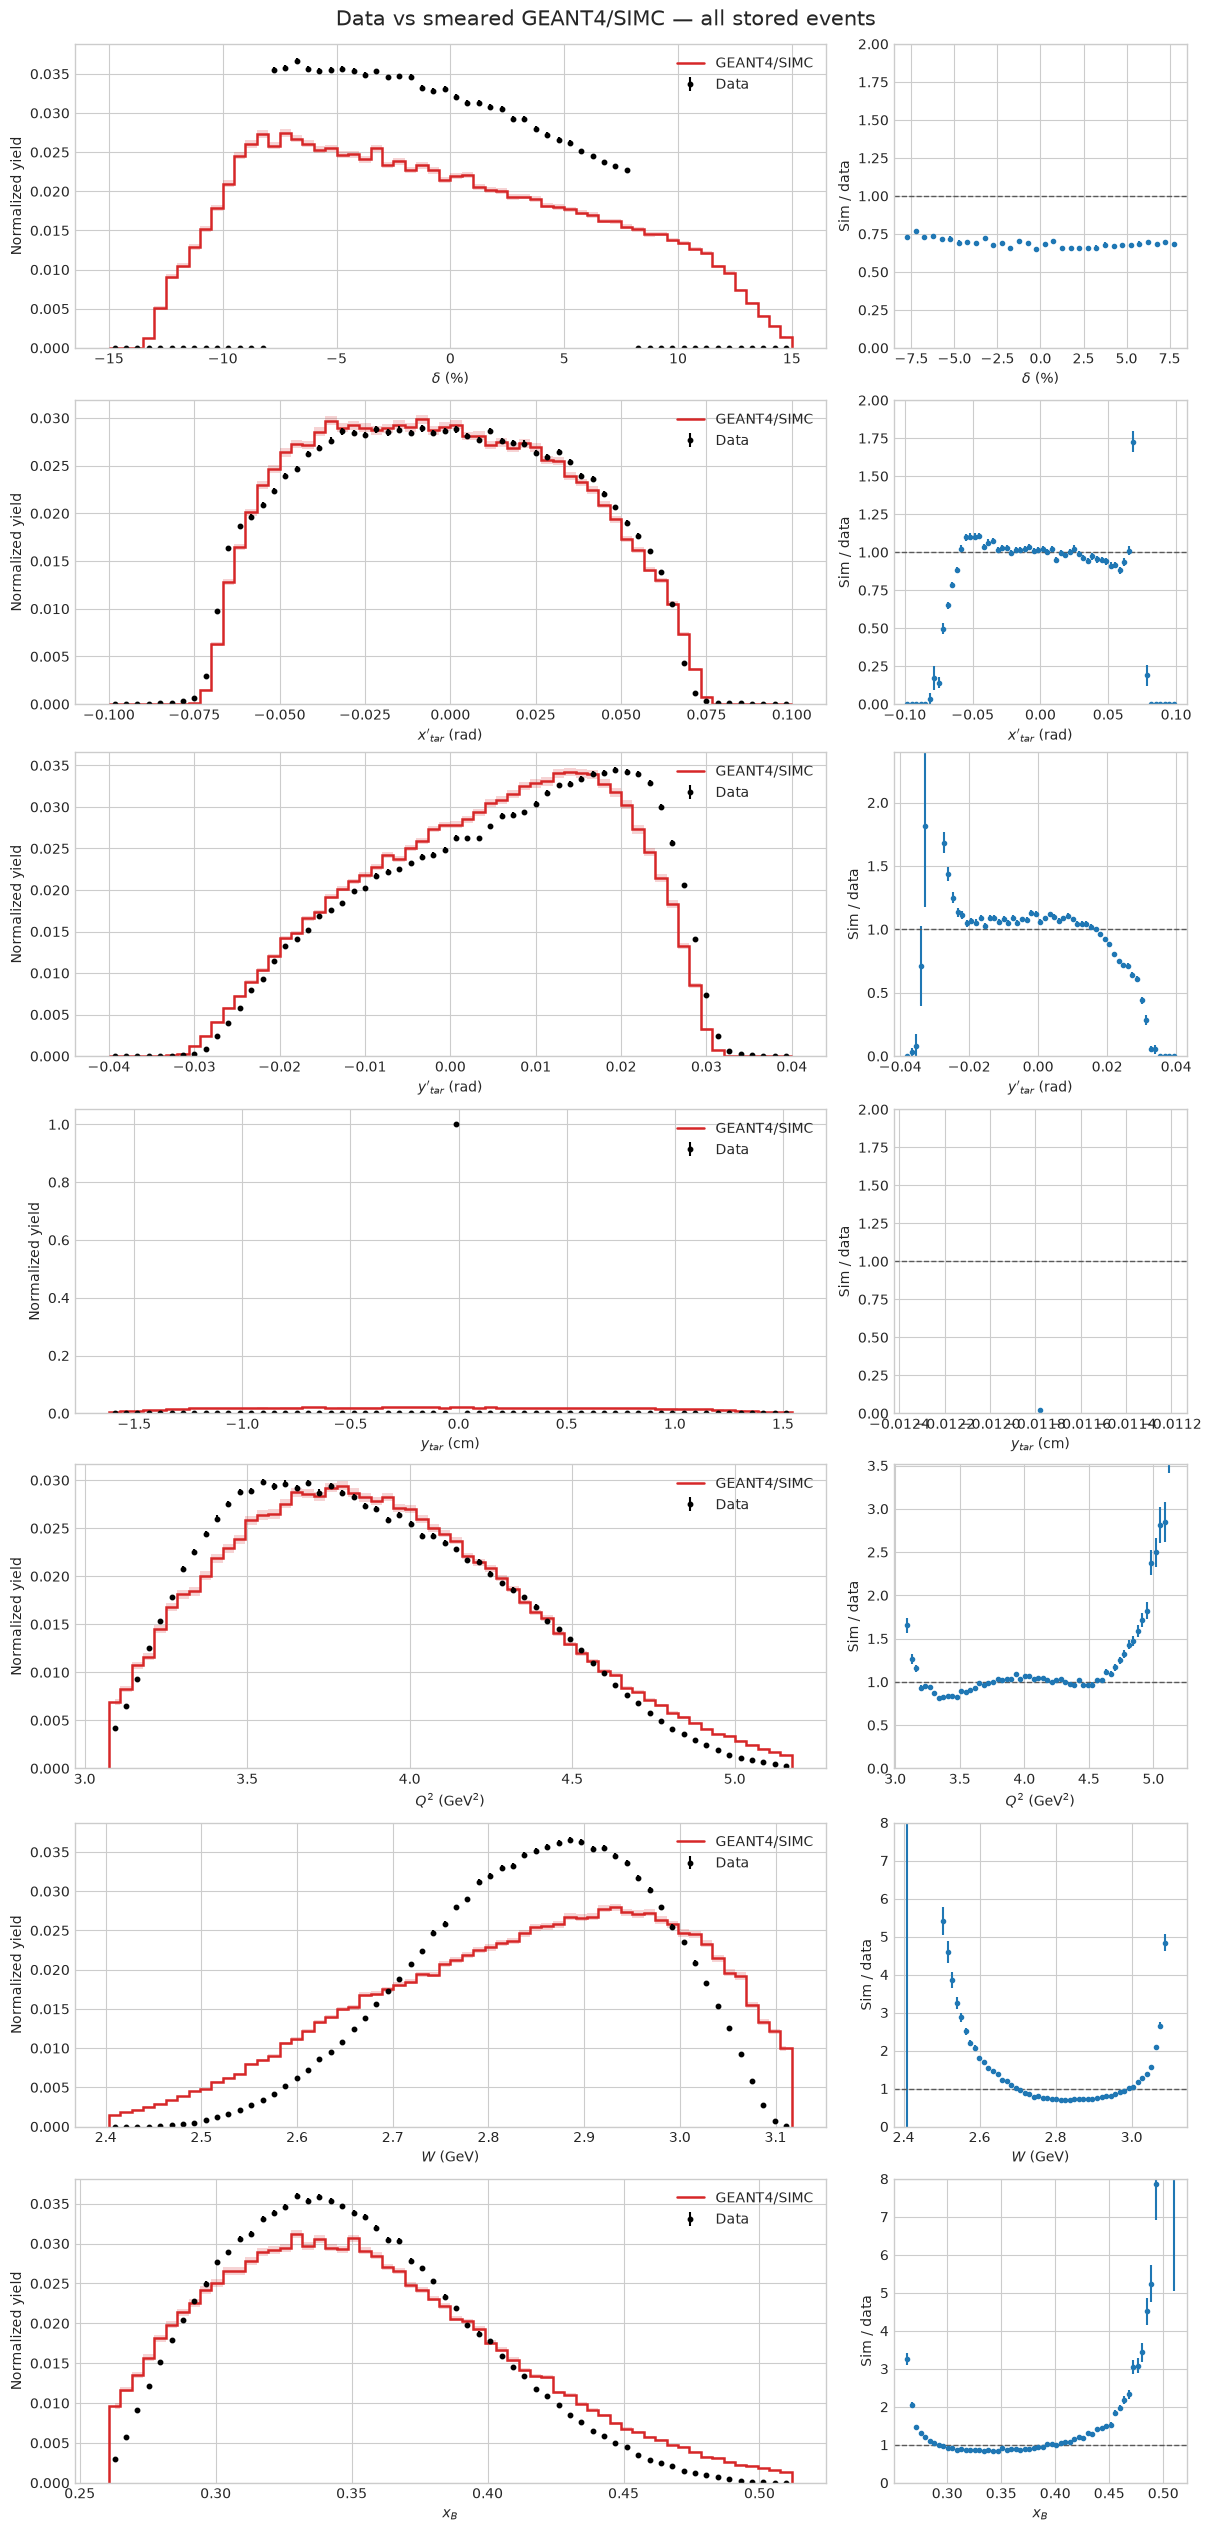

In [5]:
def normalized_hist(values, weights, edges):
    counts, _ = np.histogram(values, bins=edges, weights=weights)
    sumw2, _ = np.histogram(values, bins=edges, weights=np.square(weights))
    norm = counts.sum()
    if norm == 0:
        return counts.astype(float), np.sqrt(sumw2)
    return counts / norm, np.sqrt(sumw2) / abs(norm)

fig, axes = plt.subplots(len(VARIABLES), 2, figsize=(12, 3.6 * len(VARIABLES)),
                         gridspec_kw={"width_ratios": (3.2, 1.25)}, constrained_layout=True)

for row, (name, cfg) in enumerate(VARIABLES.items()):
    ax, rax = axes[row]
    plot_range = cfg["range"]
    if plot_range is None:
        merged = np.concatenate((data[name].to_numpy(), sim[name].to_numpy()))
        plot_range = tuple(np.nanpercentile(merged, (0.5, 99.5)))
    edges = np.linspace(*plot_range, N_BINS + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    dh, de = normalized_hist(data[name], data.weight, edges)
    sh, se = normalized_hist(sim[name], sim.weight, edges)
    ax.errorbar(centers, dh, yerr=de, fmt="o", ms=3.2, color="black", label="Data")
    ax.stairs(sh, edges, color="tab:red", linewidth=1.8, label="GEANT4/SIMC")
    ax.fill_between(centers, np.maximum(sh - se, 0), sh + se, step="mid",
                    color="tab:red", alpha=0.20, linewidth=0)
    ax.set_ylabel("Normalized yield")
    ax.set_xlabel(cfg["label"])
    ax.legend(frameon=False)

    valid = dh > 0
    ratio = np.full_like(dh, np.nan)
    ratio_err = np.full_like(dh, np.nan)
    ratio[valid] = sh[valid] / dh[valid]
    ratio_err[valid] = np.sqrt((se[valid] / dh[valid]) ** 2 +
                               (sh[valid] * de[valid] / dh[valid] ** 2) ** 2)
    rax.errorbar(centers[valid], ratio[valid], yerr=ratio_err[valid], fmt="o",
                 ms=3, color="tab:blue")
    rax.axhline(1.0, color="0.35", linestyle="--", linewidth=1)
    rax.set_xlabel(cfg["label"])
    rax.set_ylabel("Sim / data")
    finite_ratio = ratio[np.isfinite(ratio)]
    if finite_ratio.size:
        upper = min(max(2.0, np.nanpercentile(finite_ratio, 95) * 1.25), 8.0)
        rax.set_ylim(0, upper)

selection_label = SELECTION if SELECTION else "all stored events"
fig.suptitle(f"Data vs smeared GEANT4/SIMC — {selection_label}", fontsize=15)
if SAVE_FIGURE:
    fig.savefig(FIGURE_PATH, dpi=180, bbox_inches="tight")
    print(f"Saved {FIGURE_PATH.resolve()}")
plt.show()